Data Exploration

In [18]:
# Importing Necessary Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import scipy.stats as stats

In [9]:
# Data Set Overview

df = pd.read_csv('../data/raw/kc_house_data.csv')

df.head()
df.info()
df.describe()
df.shape
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

<Axes: >

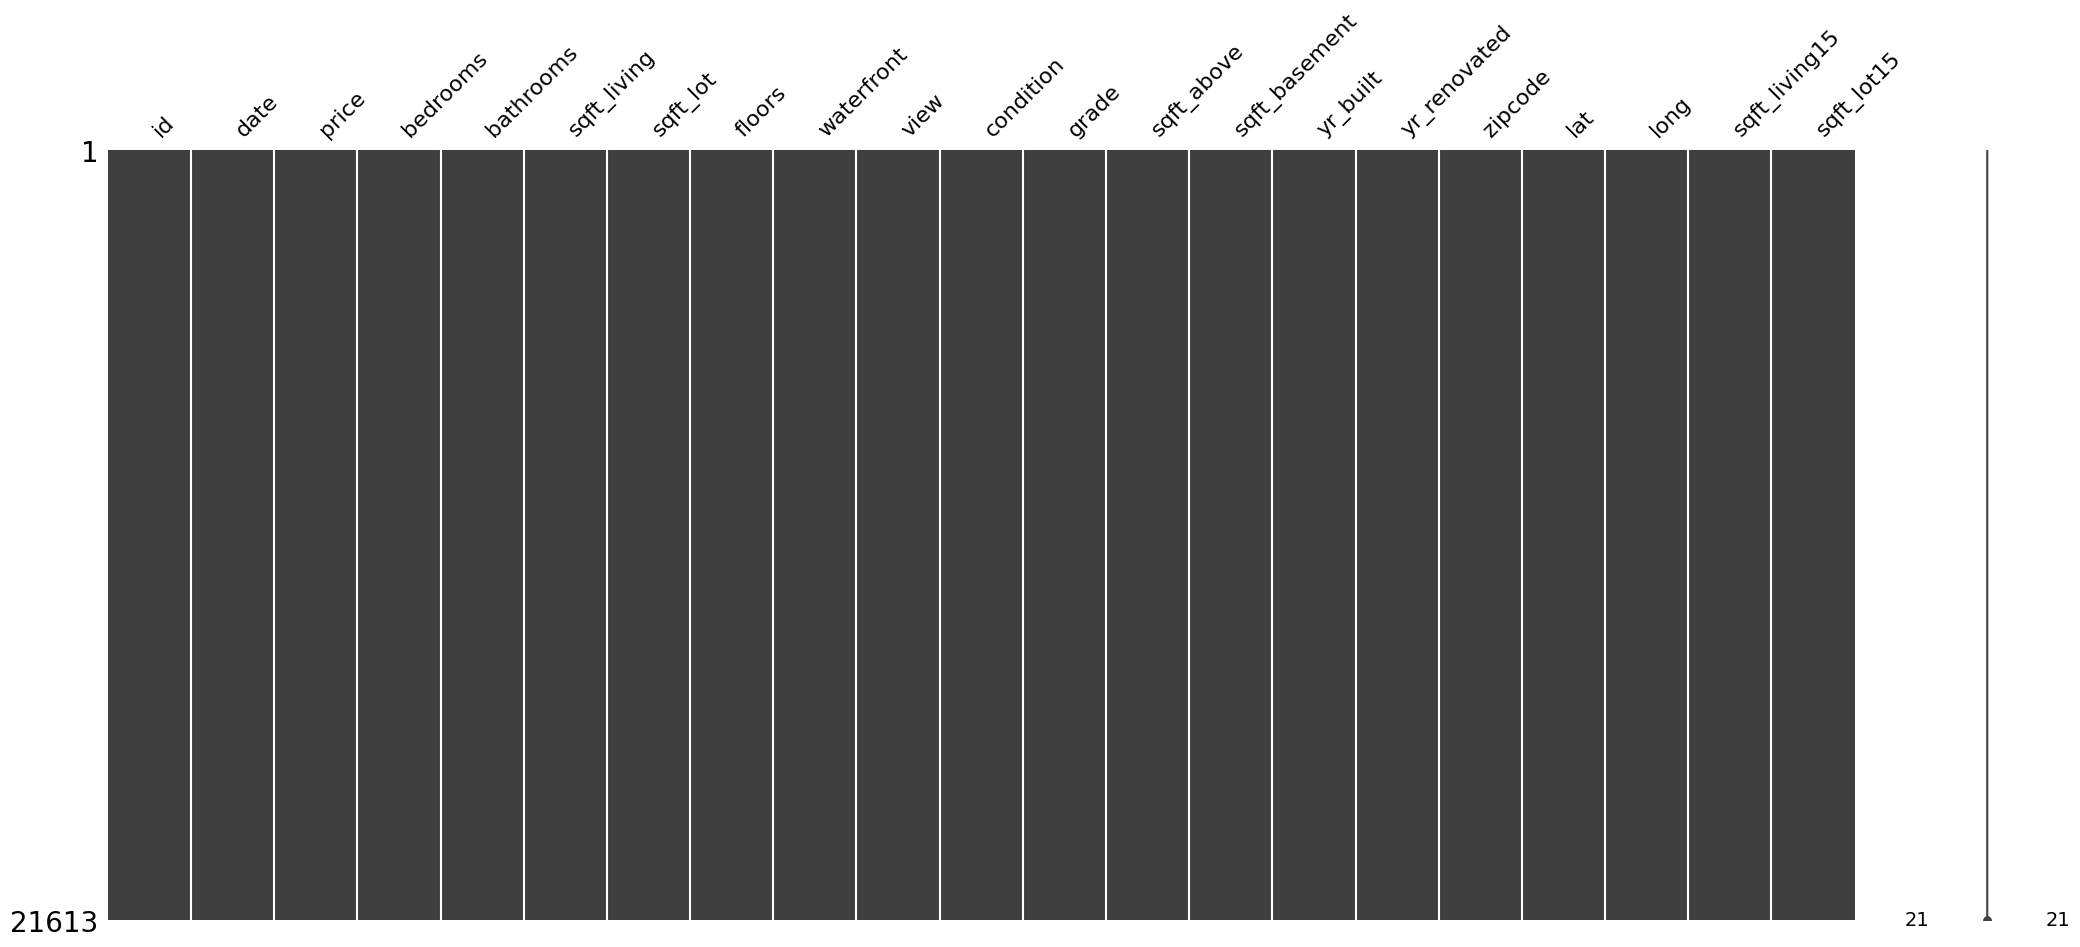

In [19]:
# Missing Values Check

df.isnull().sum()
df.isnull().mean() * 100

msno.matrix(df)

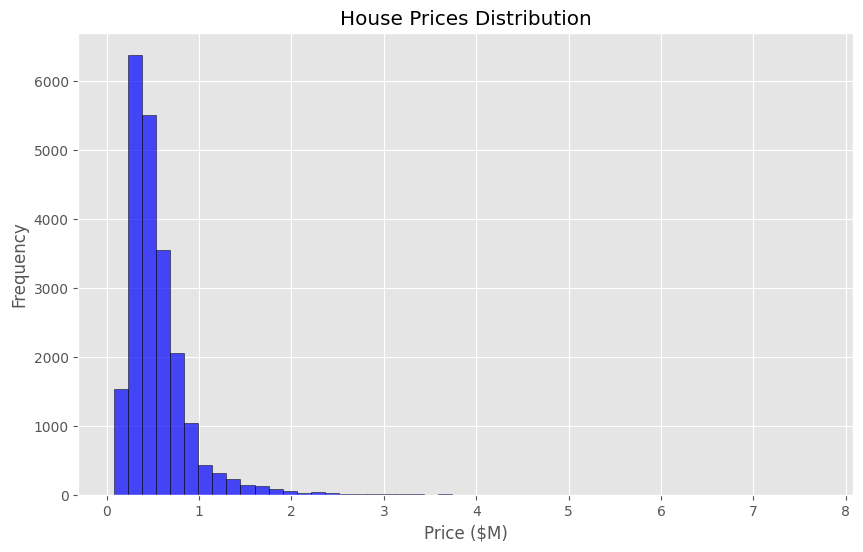

Mean Price: $540,088.14
Median Price: $450,000.00
Mode Price: $350,000.00
Price - Minimum: $75,000.00
Price - Maximum: $7,700,000.00
Price - Range: $7,625,000.00
Price - Standard Deviation: $367,127.20
Price - Skewness: 4.02
Lower Bound (1 SD): $172,960.95 and Upper Bound (1 SD): $907,215.34
Percentage of houses within 1 standard deviation: 88.90%


In [60]:
# Target Variable - Sale Price Analysis

plt.figure(figsize=(10, 6))
plt.hist(df['price']/1000000, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.title('House Prices Distribution')
plt.xlabel('Price ($M)')
plt.ylabel('Frequency')
plt.show()

df['price'].describe()
print(f'Mean Price: ${df['price'].mean():,.2f}')
print(f'Median Price: ${df['price'].median():,.2f}')
print(f'Mode Price: ${df['price'].mode()[0]:,.2f}')
print(f'Price - Minimum: ${df['price'].min():,.2f}')
print(f'Price - Maximum: ${df['price'].max():,.2f}')
print(f'Price - Range: ${df['price'].max() - df['price'].min():,.2f}')
print(f'Price - Standard Deviation: ${df['price'].std():,.2f}')
print(f'Price - Skewness: {df['price'].skew():.2f}')

mean_price = df['price'].mean()
std_price = df['price'].std()

lower_bound = mean_price - 1 * std_price
upper_bound = mean_price + 1 * std_price

within_1_std = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
percentage_within_1_std = (len(within_1_std) / len(df)) * 100
print(f'Lower Bound (1 SD): ${lower_bound:,.2f} and Upper Bound (1 SD): ${upper_bound:,.2f}')
print(f'Percentage of houses within 1 standard deviation: {percentage_within_1_std:.2f}%')


###  Target Variable Analysis - What I found with data:

- Mean > Median > Mode & the plot distribution shows it is *right skewed*.  
- Standard Deviation:
    - Huge variation
    - Almost 89% within the 1 SD. So very few houses below $173K and Luxury houses above $907K forming a long right tail.
- Skewness:
    - Extremely right-skewed. Multi-million dollar houses are extreme outlier pulling ditribution. 


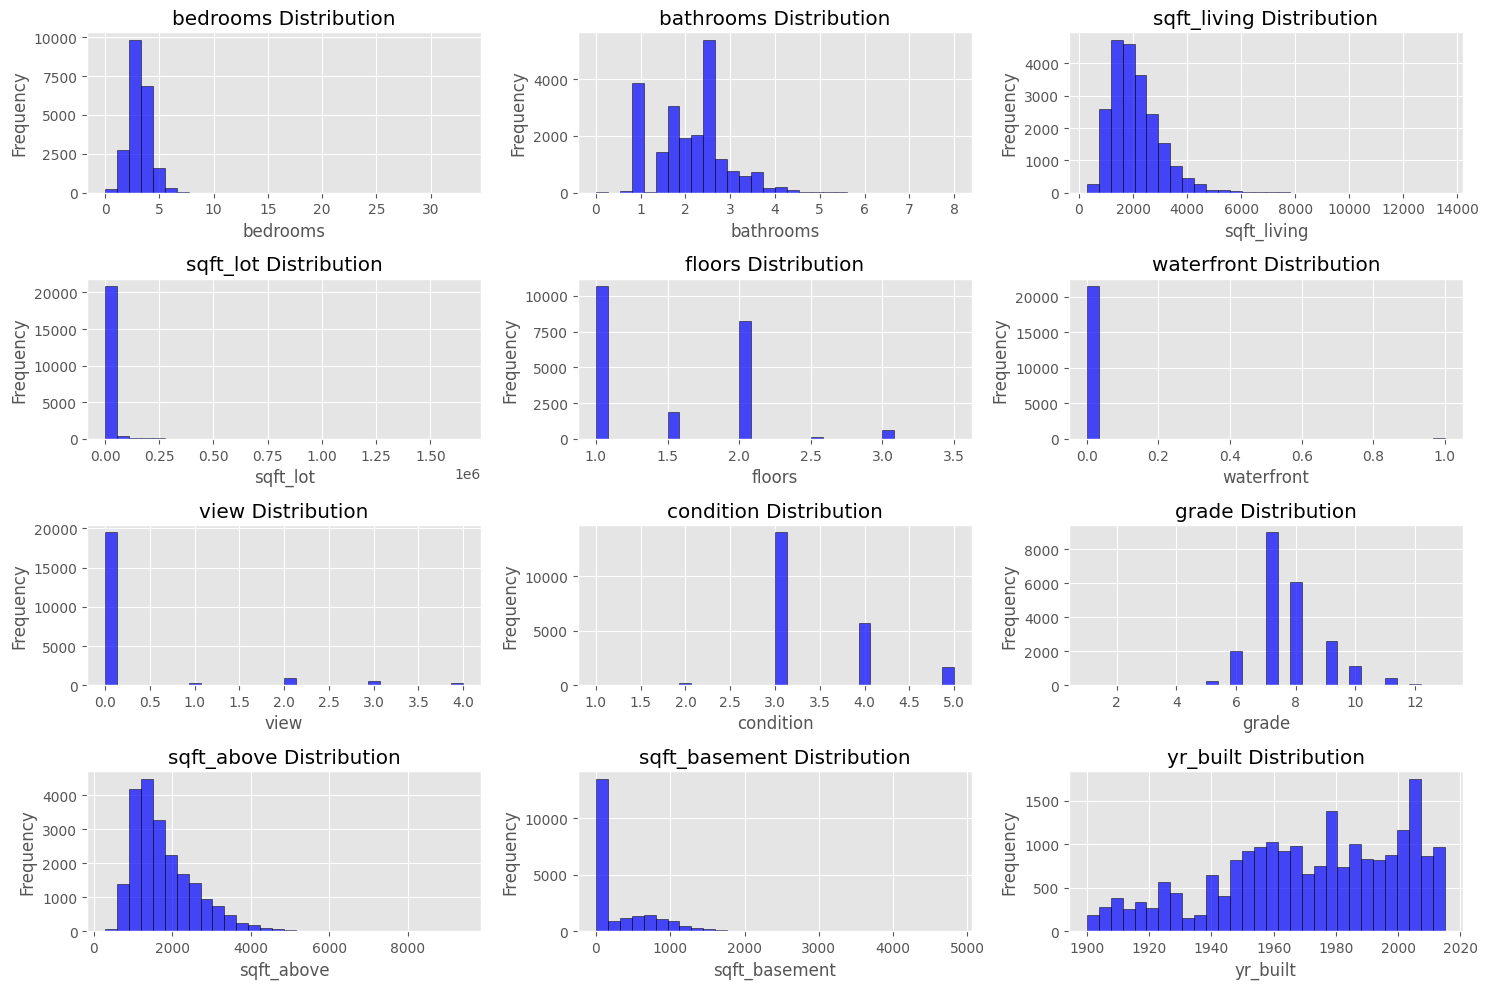

In [ ]:
# Feature Distributions

features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built']

fig, axes = plt.subplots(4, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=30, color='b', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feature} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Feature distribution Analysis

1. *Bedrooms*
    - 3 & 4 bedrooms are norm. 
    - Right skewed and fairly concentrated between 2 & 5. 

2. *Bathrooms*
    - Highest peak is 2.5 bathrooms.
    - 2 to 3 bathrooms are typical. 
    - Distribution fairly normal (slightly right skewed)

3. *Sqft Living:*
    - Right skewed 
    - Most homes between 1000 to 3000 sqft
    - Maybe Log transformation for this feature & maybe strong predictor of our target variable.

4. *Sqft Lot:*
    - Extremely right skewed
    - Most houses have between 5000 to 15000 sqft lot

5. *Floor Distribution*
    - Most homes are 1 floor or 2 floors. 
    - Can I treat it as Categorical?

6. *Year Built*
    - Fairly uniform distribution. 
    - Maybe need to create age feature: *Current year - yr_built*

Feature Correlations with Price:

Strong (r > 0.5):
  1. sqft_living: 0.7020
  2. grade: 0.6674
  3. sqft_above: 0.6056
  4. sqft_living15: 0.5854
  5. bathrooms: 0.5251

Moderate (0.3 < r <= 0.5):
  1. view: 0.3973
  2. sqft_basement: 0.3238
  3. bedrooms: 0.3083
  4. lat: 0.3070

Weak (r <= 0.3):
  1. waterfront: 0.2664
  2. floors: 0.2568
  3. yr_renovated: 0.1264
  4. sqft_lot: 0.0897
  5. sqft_lot15: 0.0824
  6. yr_built: 0.0540
  7. zipcode: -0.0532
  8. condition: 0.0364
  9. long: 0.0216


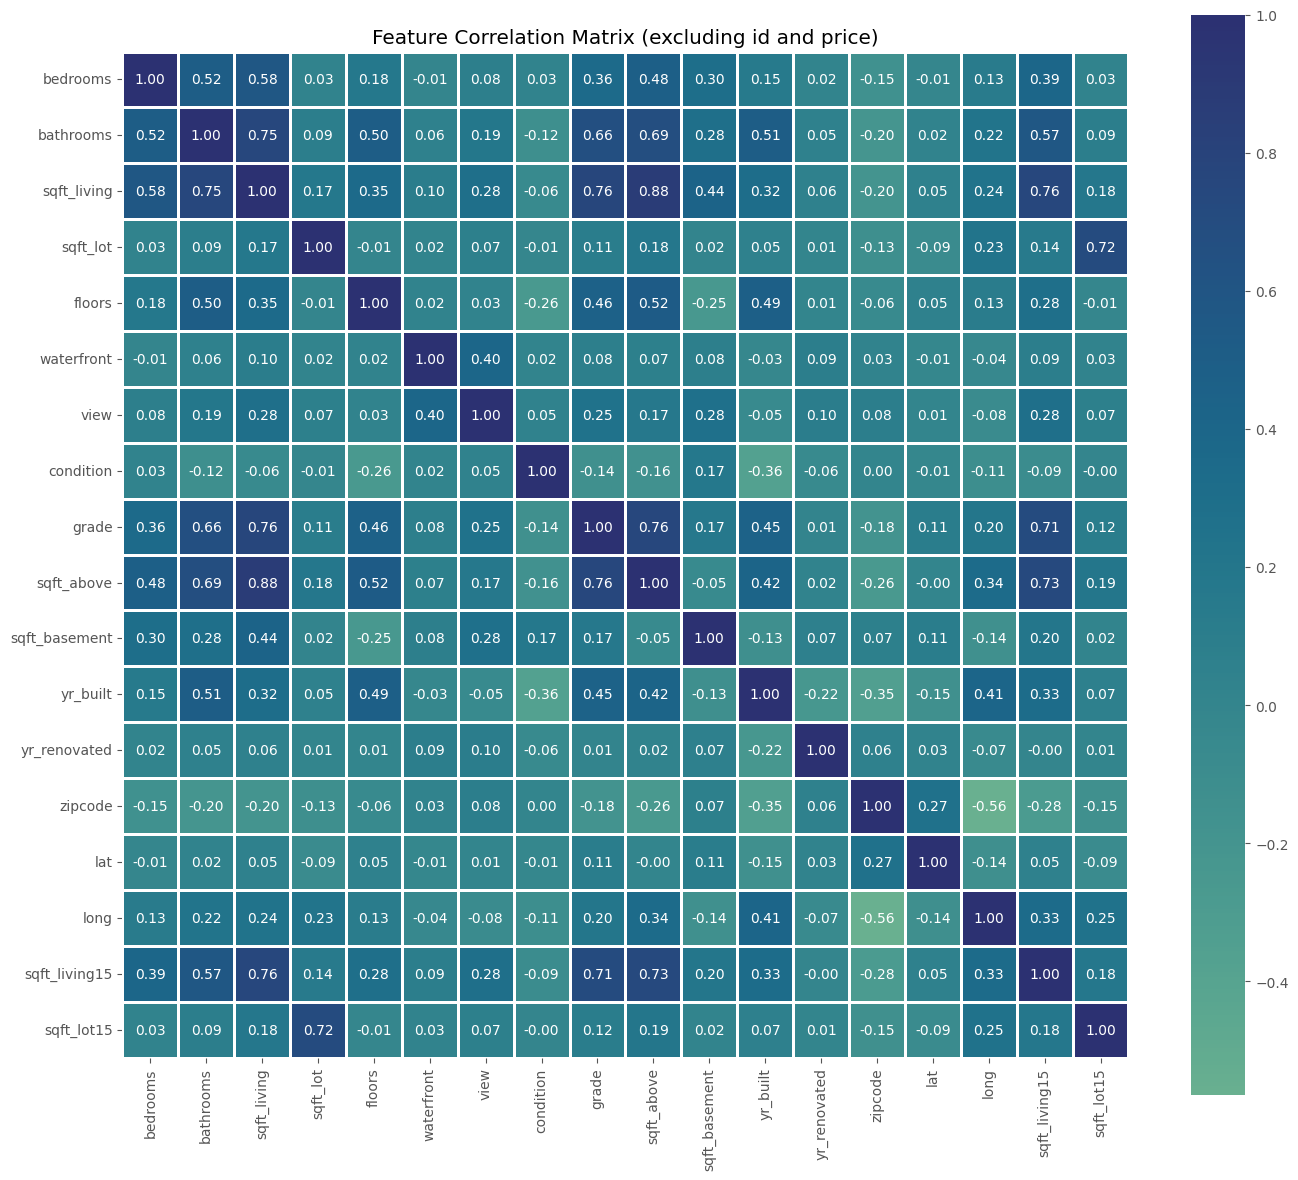

In [ ]:
# Coorrelation Analysis

numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.drop(['id', 'price'], axis=1)

correlation = numeric_df.corrwith(df['price']).sort_values(ascending=False)



print("Feature Correlations with Price:")
cats = {
    'Strong (r > 0.5)': [],
    'Moderate (0.3 < r <= 0.5)': [],
    'Weak (r <= 0.3)': [],
}
for feature, corr_value in correlation.items():
    if feature in ['id', 'price']:
        continue
    absolute_corr = abs(corr_value)
    if absolute_corr > 0.5:
        cats['Strong (r > 0.5)'].append((feature, corr_value))
    elif 0.3 < absolute_corr <= 0.5:
        cats['Moderate (0.3 < r <= 0.5)'].append((feature, corr_value))
    else:
        cats['Weak (r <= 0.4)'].append((feature, corr_value))
for category, features in cats.items():
    print(f"\n{category}:")
    if features:
        features.sort(key=lambda x: abs(x[1]), reverse=True)
        for rank, (feature, corr_value) in enumerate(features, start=1):
            print(f"  {rank}. {feature}: {corr_value:.4f}")
    else:
        print("  None")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', center=0, fmt='.2f', 
            square=True, linewidths=1)
plt.title('Feature Correlation Matrix (excluding id and price)')
plt.tight_layout()
plt.show()


### Correlation Analysis Notes

- Size & Grade (Quality) are top 2 drivers. 
- Bedrooms have weaker correlation compared to bathrooms. 
    - Possibly 3 Bed 3 Bath house > 4 bed 2 bath houses?...
- Year Built:
    - Might need house_age since no linear relationship. 


In [ ]:
# Multi Collinearity Analysis

print("\nChecking multicollinearity:")
print(f"sqft_living ↔ sqft_above: {df[['sqft_living', 'sqft_above']].corr().iloc[0,1]:.3f}")
print(f"sqft_living ↔ bathrooms: {df[['sqft_living', 'bathrooms']].corr().iloc[0,1]:.3f}")
print(f"sqft_living15 ↔ sqft_living: {df[['sqft_living15', 'sqft_living']].corr().iloc[0,1]:.3f}")


Checking multicollinearity:
sqft_living ↔ sqft_above: 0.877
sqft_living ↔ bathrooms: 0.755
sqft_living15 ↔ sqft_living: 0.756


### Multi Collinearity Notes

- Need to drop *sqft_above* since model cannot distinguish their separation. Also, *sqft_living* = sqft_above + sqft_basement
- Regression coefficients become unstable. 
- Keeping only *sqft_living* since total space is better

9 features Plot: ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat']



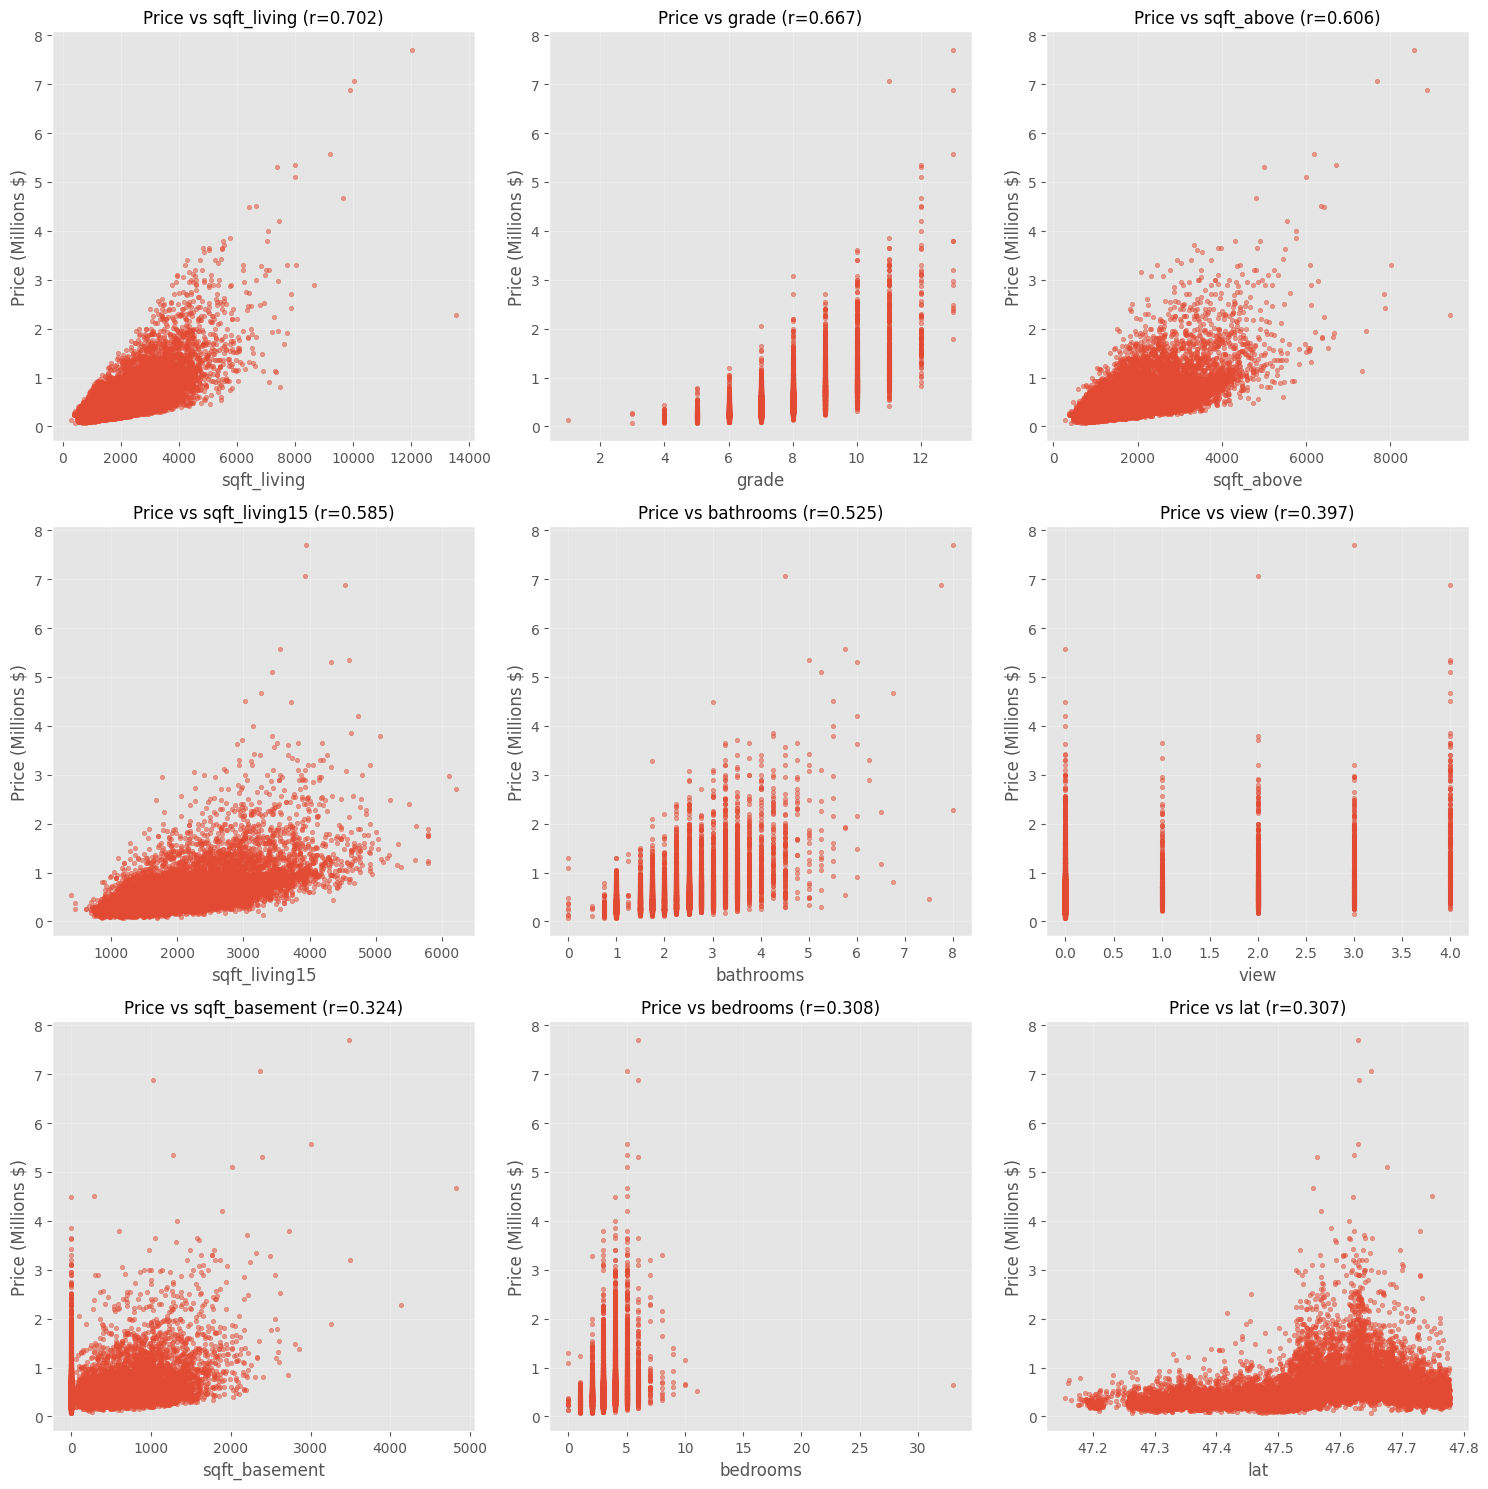

In [86]:
# Price vs Key Features (Strong & Moderate) Scatter Plots

strong_moderate_features = []

for feature, corr_value in correlation.items():
    if abs(corr_value) >= 0.3:
        strong_moderate_features.append((feature, corr_value))

strong_moderate_features.sort(key=lambda x: abs(x[1]), reverse=True)
features_to_plot = [f[0] for f in strong_moderate_features]

print(f"{len(features_to_plot)} features Plot: {features_to_plot}\n")

n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    axes[i].scatter(df[feature], df['price']/1000000, alpha=0.5, s=10)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Price (Millions $)', fontsize=12)
    
    corr_val = correlation[feature]
    axes[i].set_title(f'Price vs {feature} (r={corr_val:.3f})', fontsize=12)
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()